<a href="https://colab.research.google.com/github/lekh-ch/webtask/blob/main/Amazondataset_NB3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

In [5]:
df = pd.read_csv('cleaned_amazon_orders1.csv')
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

/tmp/ipykernel_956/1379239379.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['OrderDate'] = pd.to_datetime(df['OrderDate'])


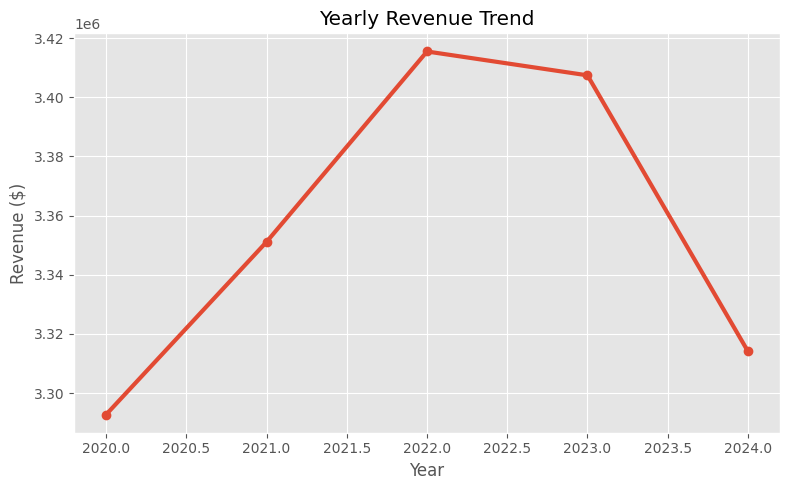

In [6]:
year_sales = (df.groupby('Year')['TotalAmount']
.sum()
.reset_index())

plt.figure(figsize=(8,5))
plt.plot(year_sales['Year'],
year_sales['TotalAmount'],
marker='o',
linewidth=3)

plt.title('Yearly Revenue Trend')
plt.xlabel('Year')
plt.ylabel('Revenue ($)')
plt.grid(True)
plt.tight_layout()
plt.show()

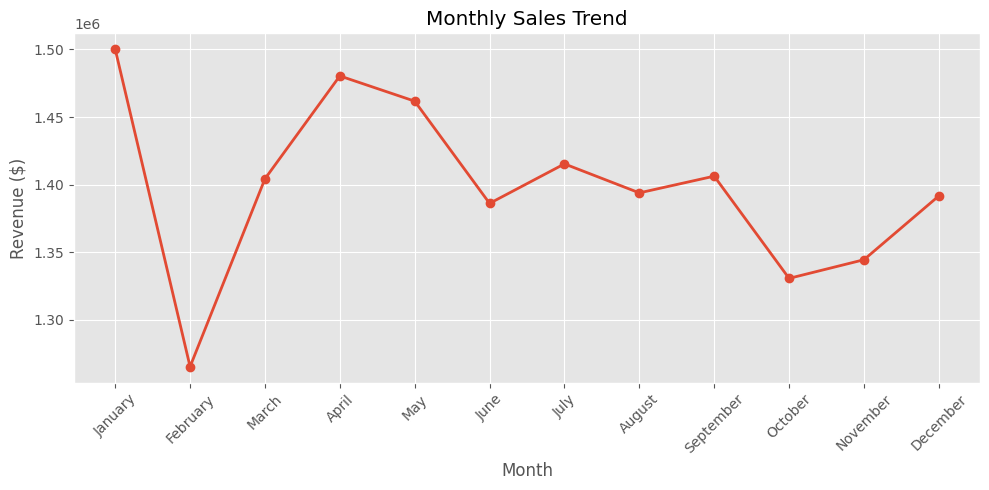

In [7]:
month_order = [
'January','February','March','April','May','June',
'July','August','September','October','November','December'
]

df['Month'] = df['OrderDate'].dt.month_name()
monthly_sales = (df.dropna(subset=['Month']).groupby('Month')['TotalAmount']
.sum()
.reset_index())

monthly_sales['Month'] = pd.Categorical(
monthly_sales['Month'],
categories=month_order,
ordered=True
)

monthly_sales = monthly_sales.sort_values('Month')

plt.figure(figsize=(10,5))
plt.plot(monthly_sales['Month'],
monthly_sales['TotalAmount'],
marker='o',
linewidth=2)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

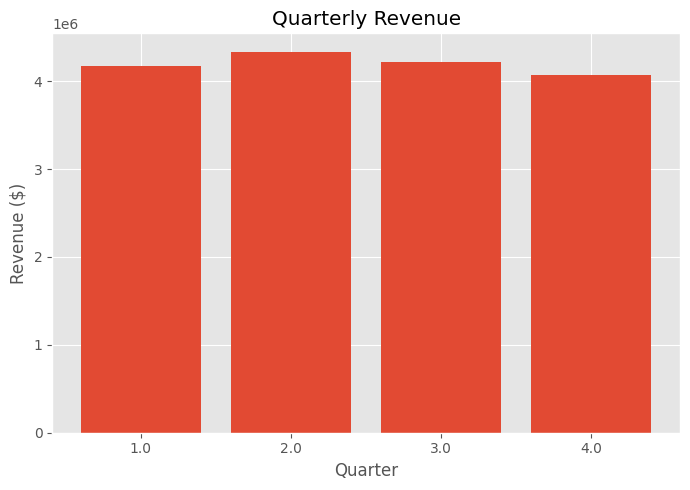

In [8]:
quarter_sales = (df.groupby('Quarter')['TotalAmount']
.sum()
.reset_index())

plt.figure(figsize=(7,5))
plt.bar(quarter_sales['Quarter'].astype(str),
quarter_sales['TotalAmount'])

plt.title('Quarterly Revenue')
plt.xlabel('Quarter')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.show()

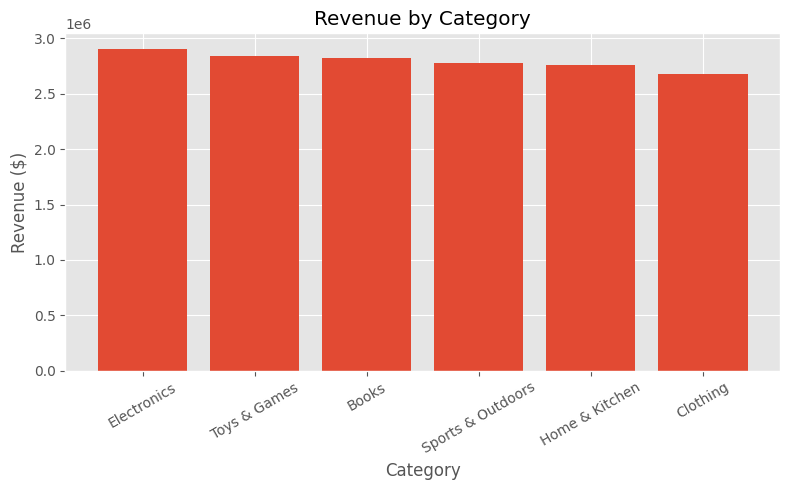

In [10]:
category_sales = (df.groupby('Category')['TotalAmount']
.sum()
.sort_values(ascending=False))

plt.figure(figsize=(8,5))
plt.bar(category_sales.index,
category_sales.values)

plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

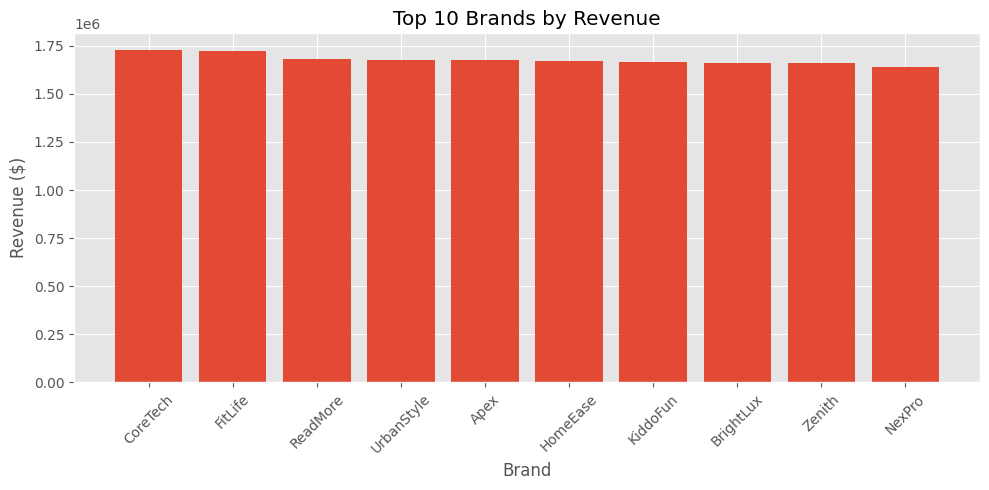

In [11]:
brand_revenue = (df.groupby('Brand')['TotalAmount']
.sum()
.sort_values(ascending=False)
.head(10))

plt.figure(figsize=(10,5))
plt.bar(brand_revenue.index,
brand_revenue.values)

plt.title('Top 10 Brands by Revenue')
plt.xlabel('Brand')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

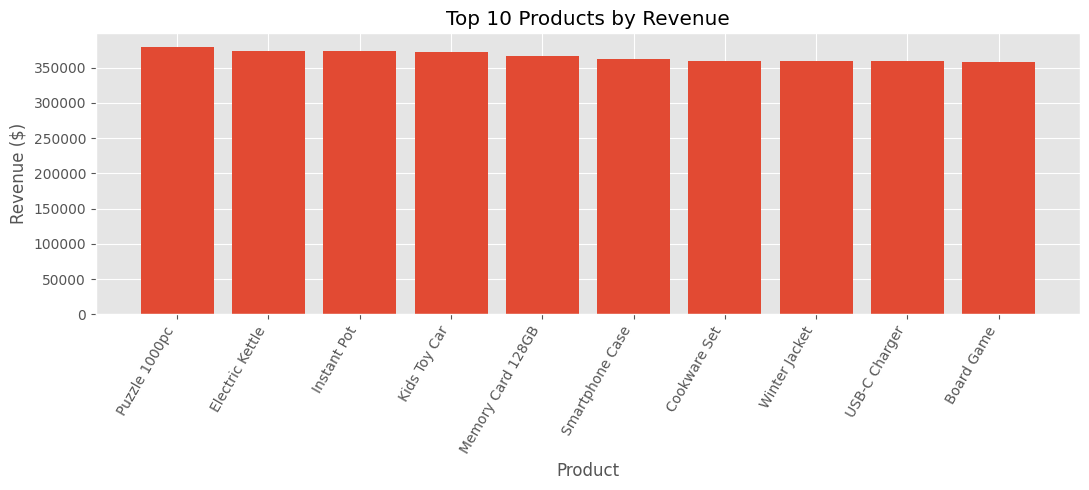

In [12]:
top_products = (df.groupby('ProductName')['TotalAmount']
.sum()
.sort_values(ascending=False)
.head(10))

plt.figure(figsize=(11,5))
plt.bar(top_products.index,
top_products.values)

plt.title('Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

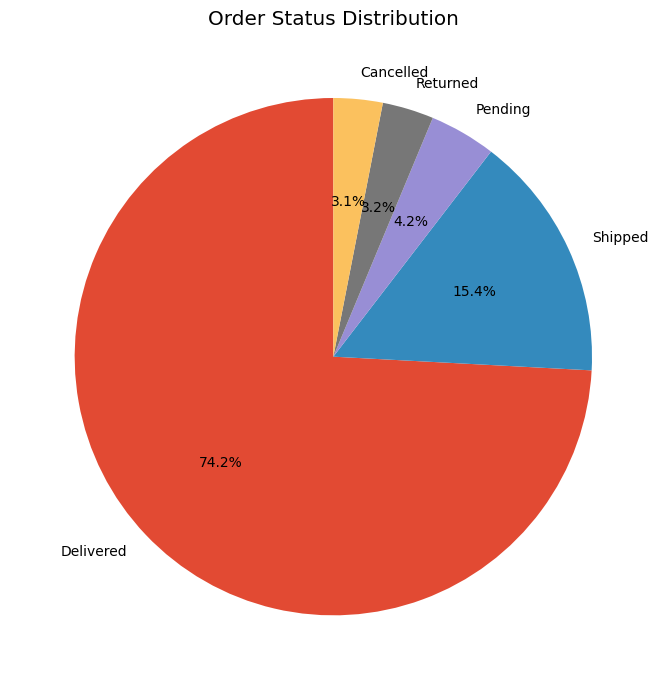

In [13]:
status_counts = df['OrderStatus'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(status_counts.values,
labels=status_counts.index,
autopct='%1.1f%%',
startangle=90)

plt.title('Order Status Distribution')
plt.tight_layout()
plt.show()

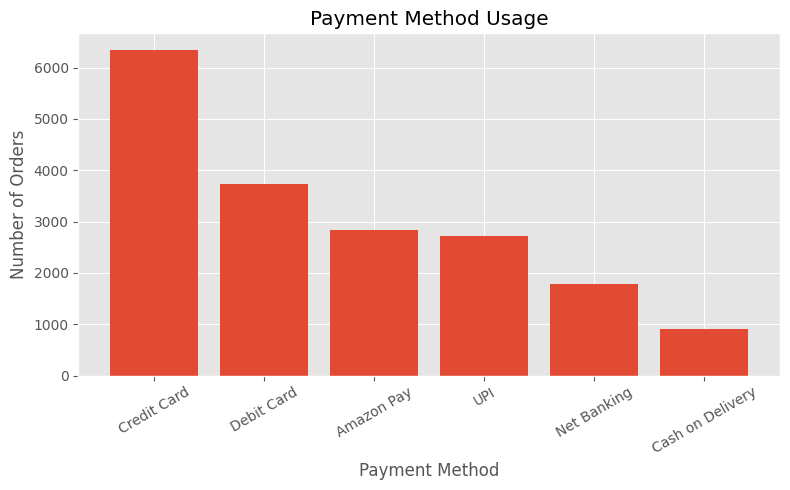

In [14]:
payment_counts = df['PaymentMethod'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(payment_counts.index,
payment_counts.values)

plt.title('Payment Method Usage')
plt.xlabel('Payment Method')
plt.ylabel('Number of Orders')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

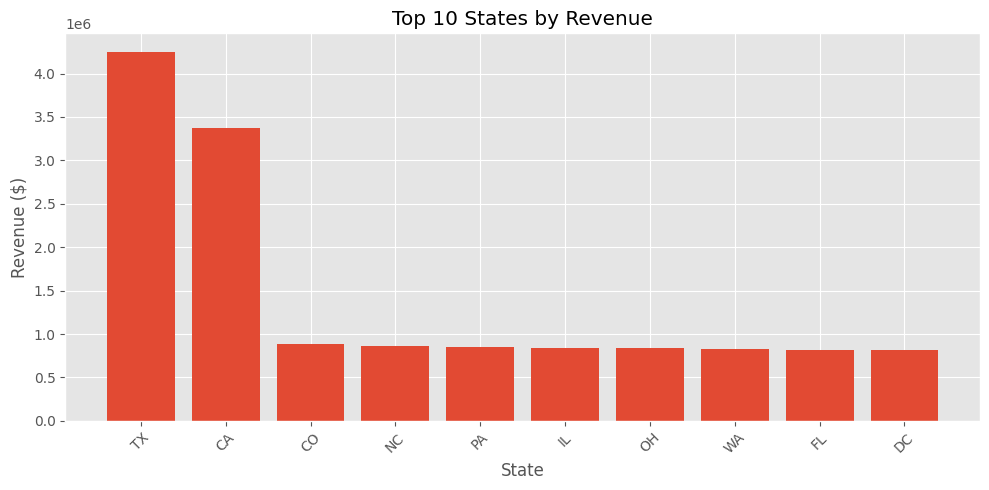

In [15]:
state_revenue = (df.groupby('State')['TotalAmount']
.sum()
.sort_values(ascending=False)
.head(10))

plt.figure(figsize=(10,5))
plt.bar(state_revenue.index,
state_revenue.values)

plt.title('Top 10 States by Revenue')
plt.xlabel('State')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

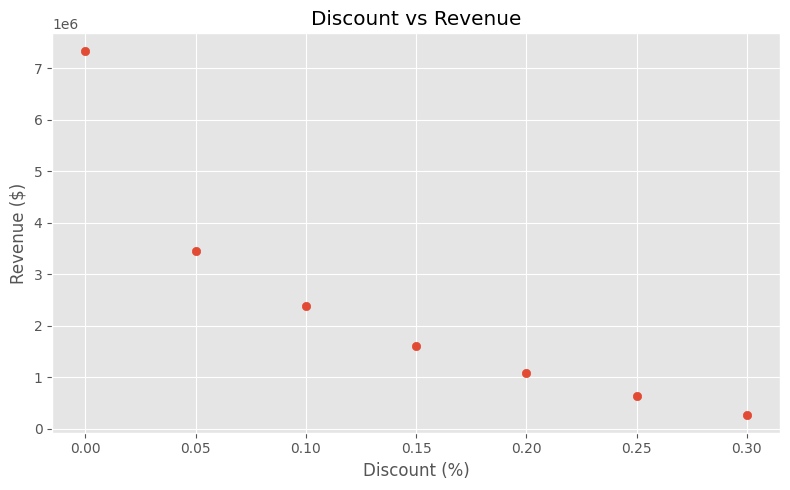

In [16]:
discount_revenue = (df.groupby('Discount')['TotalAmount']
.sum()
.reset_index())

plt.figure(figsize=(8,5))
plt.scatter(discount_revenue['Discount'],
discount_revenue['TotalAmount'])

plt.title('Discount vs Revenue')
plt.xlabel('Discount (%)')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.show()

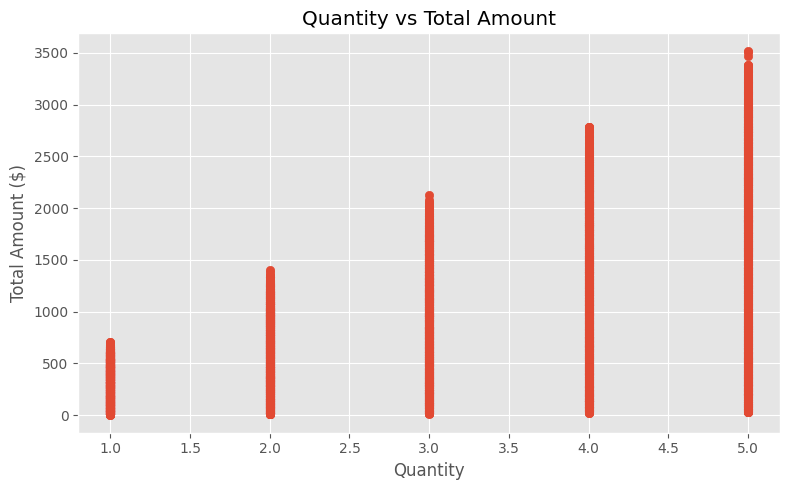

In [17]:
plt.figure(figsize=(8,5))
plt.scatter(df['Quantity'],
df['TotalAmount'])

plt.title('Quantity vs Total Amount')
plt.xlabel('Quantity')
plt.ylabel('Total Amount ($)')
plt.tight_layout()
plt.show()

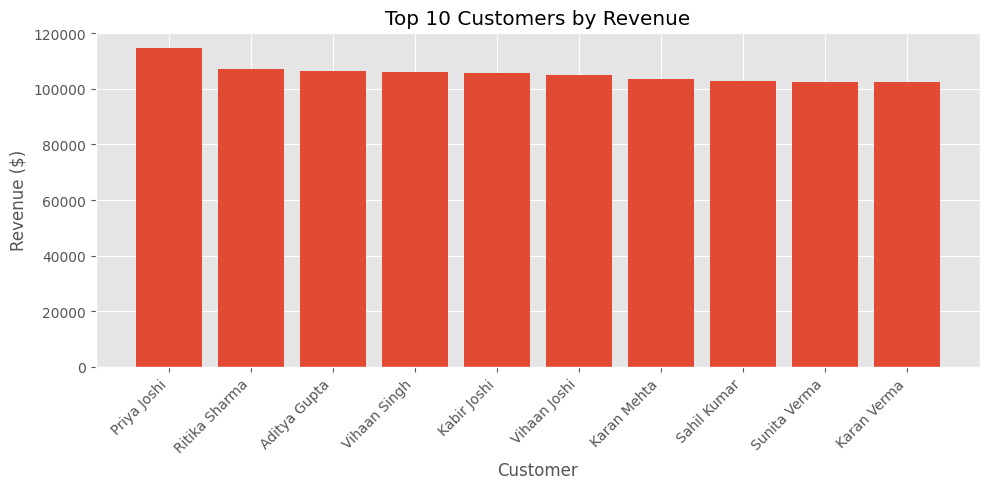

In [18]:
top_customers = (df.groupby('CustomerName')['TotalAmount']
.sum()
.sort_values(ascending=False)
.head(10))

plt.figure(figsize=(10,5))
plt.bar(top_customers.index,
top_customers.values)

plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

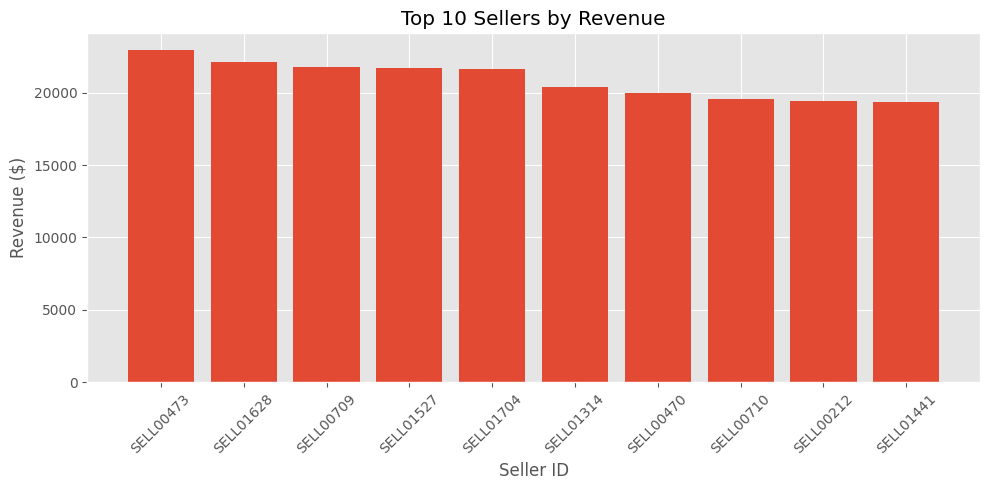

In [19]:
top_sellers = (df.groupby('SellerID')['TotalAmount']
.sum()
.sort_values(ascending=False)
.head(10))

plt.figure(figsize=(10,5))
plt.bar(top_sellers.index.astype(str),
top_sellers.values)

plt.title('Top 10 Sellers by Revenue')
plt.xlabel('Seller ID')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

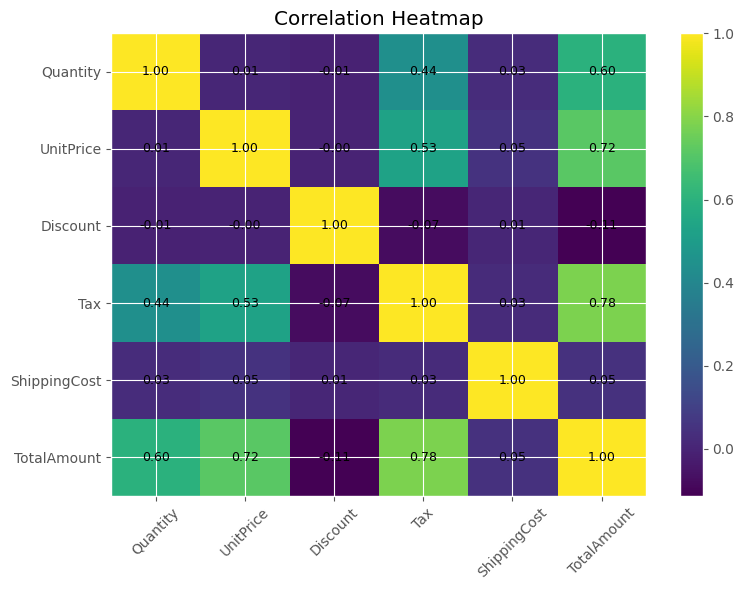

In [21]:
numeric_cols = [
'Quantity',
'UnitPrice',
'Discount',
'Tax',
'ShippingCost',
'TotalAmount'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, interpolation='nearest', aspect='auto')

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title('Correlation Heatmap')

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i,
                 f'{corr.iloc[i,j]:.2f}',
                 ha='center',
                 va='center',
                 fontsize=9)

plt.tight_layout()
plt.show()

In [22]:
print('Top Revenue Year :', year_sales.loc[year_sales['TotalAmount'].idxmax(), 'Year'])
print('Top Revenue Month :', monthly_sales.loc[monthly_sales['TotalAmount'].idxmax(), 'Month'])
print('Top Revenue Quarter :', quarter_sales.loc[quarter_sales['TotalAmount'].idxmax(), 'Quarter'])
print('Top Category :', category_sales.idxmax())
print('Top Brand :', brand_revenue.idxmax())
print('Top Product :', top_products.idxmax())
print('Most Used Payment :', payment_counts.idxmax())
print('Most Common OrderStatus:', status_counts.idxmax())
print('Top State :', state_revenue.idxmax())

Top Revenue Year : 2022.0
Top Revenue Month : January
Top Revenue Quarter : 2.0
Top Category : Electronics
Top Brand : CoreTech
Top Product : Puzzle 1000pc
Most Used Payment : Credit Card
Most Common OrderStatus: Delivered
Top State : TX
